In [1]:
from eeg_music.data import EEGMusicDataset
from pathlib import Path
train_ds = EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_train_onesubj_ica_40ch/"))
test_ds =EEGMusicDataset.load_ondisk(Path("./datasets/bcmi_preprocessed/bcmi_test_onesubj_ica_40ch/"))
len(train_ds), len(test_ds)

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


(3456, 3456)

In [2]:
from fractions import Fraction
from eeg_music.data import ArrayStratifiedSamplingDataset

train_ds_strat = ArrayStratifiedSamplingDataset(train_ds, 10, trial_length_secs=Fraction(1, 1))
test_ds_strat =  ArrayStratifiedSamplingDataset(test_ds, 10, trial_length_secs=Fraction(1, 1))

In [ ]:
sample = train_ds[0]

('bcmi-training', '10', '3', '1', 'trial_1')

In [ ]:
test_ds_strat[0].

In [23]:
# Reverse lookup: tuple -> integer position
key = train_ds.df.index[0]
print("key:", key)
print("position:", train_ds.df.index.get_loc(key))

key: ('bcmi-training', '10', '3', '1', 'trial_1')
position: 0


In [ ]:
import numpy as np
def create_X_y(dataset):
    # works for RepeatedDataset(ArrayStratifiedSamplingDataset(ds))
    X = []
    y = []
    for i in range(len(dataset)):
        sample = dataset[i]
        X.append(sample.eeg_data.get_array().data)
        y.append(dataset.dataset.df.index.get_loc((sample.dataset, sample.subject, sample.session, sample.run, sample.trial_id)))
    return np.array(X), np.array(y)

# X_train, y_train = create_X_y(train_ds_strat)
# X_train.shape, y_train.shape 

In [31]:
from eeg_music.data import RepeatedDataset

train_ds_repeated = RepeatedDataset(train_ds_strat, 2)
test_ds_repeated = RepeatedDataset(test_ds_strat, 2)

X_train, y_train = create_X_y(train_ds_repeated)
X_test, y_test = create_X_y(test_ds_repeated)

In [32]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Flatten EEG data for traditional ML models (samples, channels, timepoints) -> (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Training set: {X_train_flat.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test_flat.shape}, Labels: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training set: (8640, 400), Labels: (8640,)
Test set: (8640, 400), Labels: (8640,)
Number of classes: 432


In [33]:
# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test_flat)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost...

XGBoost Test Accuracy: 0.7755

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.40      0.47        20
           1       0.95      1.00      0.98        20
           2       0.83      1.00      0.91        20
           3       1.00      1.00      1.00        20
           4       0.36      0.95      0.52        20
           5       0.93      0.70      0.80        20
           6       0.72      0.90      0.80        20
           7       0.74      1.00      0.85        20
           8       0.59      0.95      0.73        20
           9       0.75      0.90      0.82        20
          10       1.00      0.65      0.79        20
          11       1.00      0.35      0.52        20
          12       1.00      0.95      0.97        20
          13       0.78      0.90      0.84        20
          14       0.87      1.00      0.93        20
          15       0.95      1.00      0.98        2

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [34]:
# Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_flat)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"\nSVM Test Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Training SVM...

SVM Test Accuracy: 0.9110

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      0.95      0.97        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.71      1.00      0.83        20
           9       1.00      0.80      0.89        20
          10       1.00      1.00      1.00        20
          11       0.69      0.55      0.61        20
          12       0.84      0.80      0.82        20
          13       1.00      1.00      1.00        20
          14       0.95      1.00      0.98        20
          15       0.59      1.00      0.74        20
          

In [35]:
# Train KNN
from sklearn.neighbors import KNeighborsClassifier
print("Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_knn = knn_model.predict(X_test_flat)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\nKNN Test Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

Training KNN...

KNN Test Accuracy: 0.8801

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.77      1.00      0.87        20
           3       1.00      1.00      1.00        20
           4       0.71      1.00      0.83        20
           5       1.00      0.85      0.92        20
           6       1.00      0.80      0.89        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.85      0.55      0.67        20
          12       0.88      0.75      0.81        20
          13       1.00      1.00      1.00        20
          14       0.91      1.00      0.95        20
          15       0.61      1.00      0.75        20
          

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [36]:
# Compare results
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"SVM Accuracy:     {svm_accuracy:.4f}")
print(f"KNN Accuracy:     {knn_accuracy:.4f}")


COMPARISON
XGBoost Accuracy: 0.7755
SVM Accuracy:     0.9110
KNN Accuracy:     0.8801


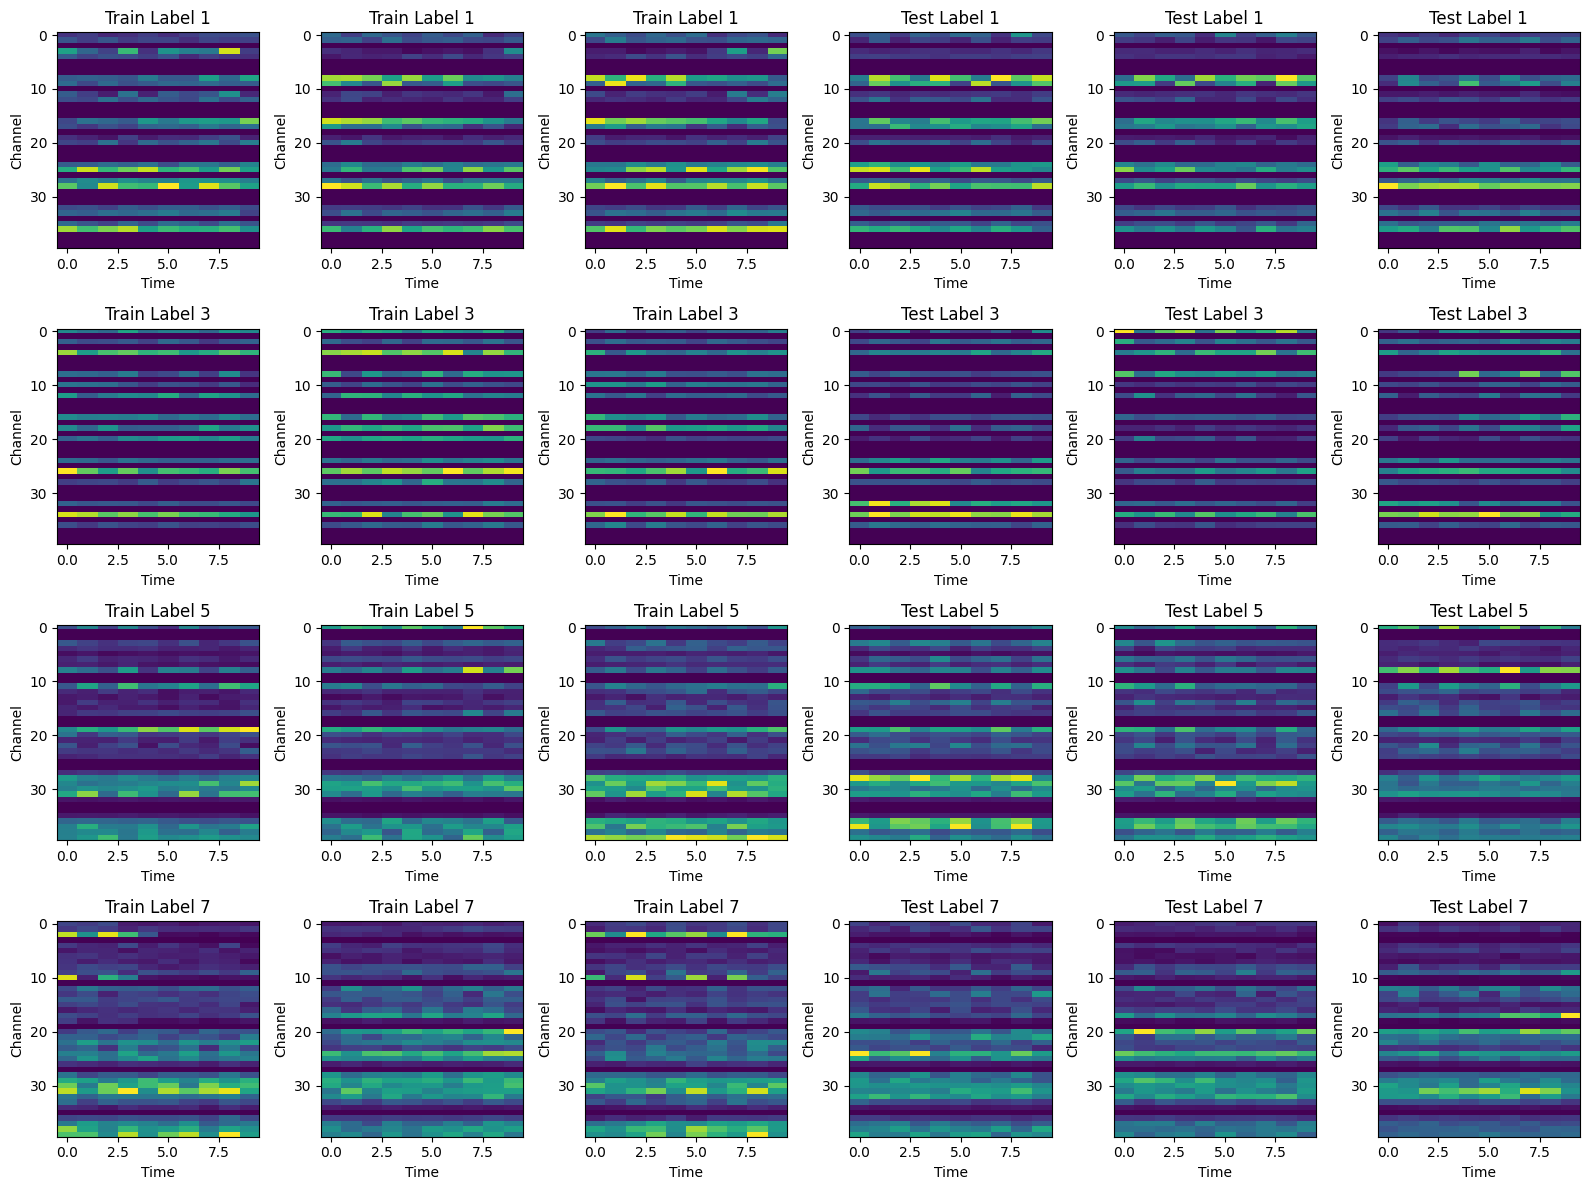

In [37]:
import matplotlib.pyplot as plt


labels_to_plot = [1, 3, 5, 7]
samples_per_label = 3

fig, axes = plt.subplots(len(labels_to_plot), 2*samples_per_label, figsize=(16, 12))

for row, label in enumerate(labels_to_plot):
    # Get train samples with this label
    train_label_indices = np.where(y_train == label)[0]
    train_sampled = np.random.choice(train_label_indices, min(samples_per_label, len(train_label_indices)), replace=False)
    
    # Get test samples with this label
    test_label_indices = np.where(y_test == label)[0]
    test_sampled = np.random.choice(test_label_indices, min(samples_per_label, len(test_label_indices)), replace=False)
    
    # Plot train samples (left side)
    for col, idx in enumerate(train_sampled):
        axes[row, col].imshow(X_train[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, col].set_title(f"Train Label {label}")
        axes[row, col].set_xlabel("Time")
        axes[row, col].set_ylabel("Channel")
    
    # Plot test samples (right side)
    for col, idx in enumerate(test_sampled):
        axes[row, samples_per_label + col].imshow(X_test[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, samples_per_label + col].set_title(f"Test Label {label}")
        axes[row, samples_per_label + col].set_xlabel("Time")
        axes[row, samples_per_label + col].set_ylabel("Channel")

plt.tight_layout()
plt.show()